# Comparative Analysis of Heart Disease Risk Factors - Dataset 2
---
A Data Science Approach for Exploring and Comparing Heart disease Risk Indicators

Dataset 2 Link source: https://www.kaggle.com/datasets/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid

In [309]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import log10

from scipy import stats
from scipy.stats import mannwhitneyu

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import seaborn as sns

from sklearn.model_selection import train_test_split

In [310]:
data = pd.read_csv('../data/Medicaldataset.csv')
data

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


In [311]:
df = data.copy()

In [312]:
df.shape

(1319, 9)

The dataset contains a relatively limited number of observations for training a Random Forest model.

Despite this, we can still perform data analysis to investigate whether specific relationships exist between cardiovascular disease and the health indicators selected in this dataset. This allows us to explore potential patterns, correlations, and risk factors associated with heart disease, even with a limited number of observations.

We will not attempt to train a Random Forest model on this dataset.

In [313]:
df.isna().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [314]:
df['Result'].value_counts()

Result
positive    810
negative    509
Name: count, dtype: int64

In [315]:
df['Result'] = df['Result'].map({
    'negative': 0,
    'positive': 1,
})

In [316]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('-', '_')
df.columns = df.columns.str.lower()

In [317]:
df

,age,gender,heart_rate,systolic_blood_pressure,diastolic_blood_pressure,blood_sugar,ck_mb,troponin,result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1
1317,54,1,58,117,68,443.0,5.80,0.359,1


Hypothesis 1 - Troponin Levels and Heart Disease

- H0 (Null Hypothesis): High troponin levels are not associated with the presence of heart disease.
- H1 (Alternative Hypothesis): High troponin levels are associated with the presence of heart disease, although some observations may show elevated troponin levels without diagnosed heart disease.

In [318]:
df['troponin'].describe()

count    1319.000000
mean        0.360942
std         1.154568
min         0.001000
25%         0.006000
50%         0.014000
75%         0.085500
max        10.300000
Name: troponin, dtype: float64

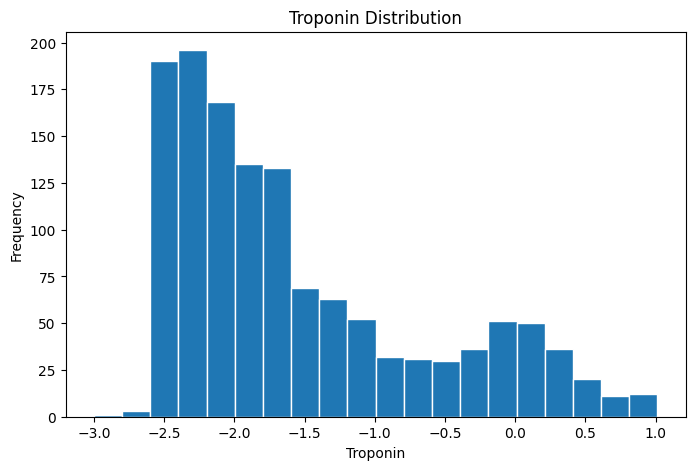

In [319]:
# Visualizing the distribution of troponin levels.

# A logarithmic transformation is applied because troponin values
# may contain extreme differences and strong right skewness.

# This helps improve the readability of the distribution.

plt.figure(figsize=(8,5))

plt.hist(log10(df['troponin']), bins=20, edgecolor='white')

plt.xlabel('Troponin')
plt.ylabel('Frequency')
plt.title('Troponin Distribution')

plt.show()

The histogram shows the distribution of logarithmically transformed troponin levels in the dataset. Most observations are concentrated in the lower troponin ranges, while fewer patients exhibit high troponin values.

The log transformation improves the visualization by reducing the impact of extreme values and making the distribution easier to interpret. Even after the transformation, the distribution still appears moderately skewed, suggesting that elevated troponin levels are less common within the dataset.

Negative values appear because a logarithmic transformation (`log10`) was applied to the troponin feature.

When the original troponin values are between 0 and 1, the logarithm becomes negative:

- `log10(0.1) = -1`
- `log10(0.01) = -2`

This does not mean that troponin levels are negative. It only indicates that some original troponin values are very small.

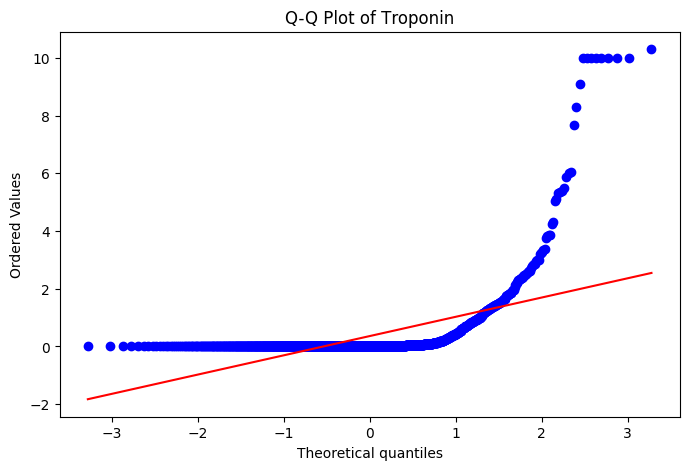

In [320]:
# Q-Q plot is used to visually check whether
# the troponin values follow a normal distribution.

# The plot compares the observed troponin values
# with the expected values from a theoretical
# normal distribution.

# If the points follow the diagonal line closely,
# the data can be considered approximately normal.

# Large deviations from the line suggest that
# the distribution is not normal
plt.figure(figsize=(8,5))
stats.probplot(df['troponin'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Тroponin')
plt.show()

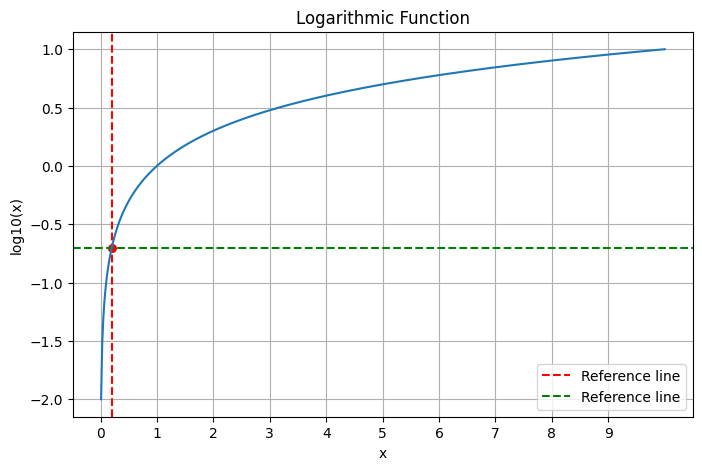

In [321]:
# Plotting the logarithmic function log10(x).
# The graph demonstrates how values between 0 and 1
# produce negative logarithmic outputs.
# Larger values increase slowly due to the logarithmic scale.
x = np.linspace(0.01, 10, 500)
y = np.log10(x)
plt.figure(figsize=(8,5))

plt.axvline(0.2, color='r', linestyle='--', label='Reference line')
plt.axhline(-0.7, color='g', linestyle='--', label='Reference line')
plt.scatter(0.2, -0.7, color='red', s=30)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('log10(x)')
plt.xticks(range(0, 10, 1))
plt.legend()
plt.title('Logarithmic Function')

plt.grid(True)
plt.show()

In [322]:
# Mann-Whitney U Test is used to compare
# the troponin distributions between
# patients with and without heart disease.

# This test is preferred because troponin
# values are usually not normally distributed.

# H0 (Null Hypothesis):
# There is no difference in troponin levels
# between the two groups.

# H1 (Alternative Hypothesis):
# Troponin levels are significantly different
# between patients with and without heart disease.

# Split the dataset into two groups:
# 1 - patients with heart disease
# 0 - patients without heart disease

# Split groups
heart_disease = df[df['result'] == 1]['troponin']
no_heart_disease = df[df['result'] == 0]['troponin']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    heart_disease,
    no_heart_disease
)

print("Statistic:", stat)
print("P-value:", p_value)

# Interpretation:
# Extremely small p-value (< 0.05)
# indicates a statistically significant
# difference between the two groups.

Statistic: 368361.5
P-value: 1.1901138042392155e-128


### Therefore, we reject H0 and conclude that troponin levels are associated with heart disease.

CK-MB (Creatine Kinase-MB) is an enzyme primarily found in heart muscle cells. It belongs to the creatine kinase enzyme family, which plays an important role in energy production within muscles.

When the heart muscle becomes damaged, such as during a heart attack or other cardiovascular conditions, CK-MB is released into the bloodstream. Elevated CK-MB levels may therefore indicate cardiac muscle injury.

CK-MB has historically been used as a biomarker for diagnosing myocardial infarction (heart attack). However, modern medicine more commonly relies on troponin tests because troponin is more specific and sensitive for detecting heart damage.

Despite this, CK-MB can still provide valuable clinical information, especially when combined with other cardiac biomarkers and diagnostic tests.

In [323]:
df['ck_mb'].describe()

count    1319.000000
mean       15.274306
std        46.327083
min         0.321000
25%         1.655000
50%         2.850000
75%         5.805000
max       300.000000
Name: ck_mb, dtype: float64

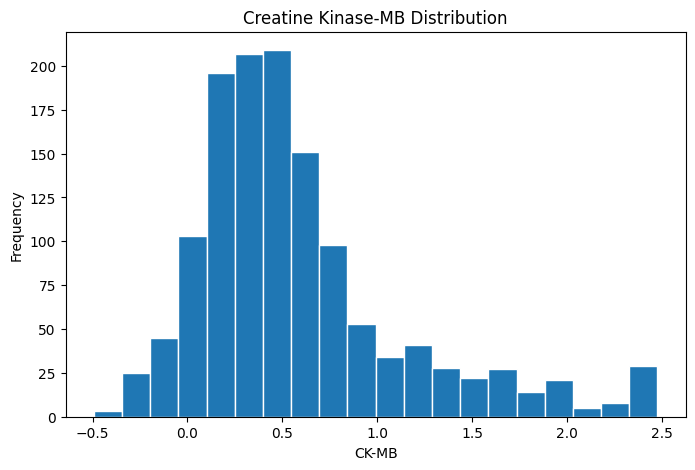

In [324]:
# Visualizing the distribution of CK-MB levels.

# A logarithmic transformation is applied because CK values
# may contain extreme differences and strong right skewness.

# This helps improve the readability of the distribution.

plt.figure(figsize=(8,5))

plt.hist(log10(df['ck_mb']), bins=20, edgecolor='white')

plt.xlabel('CK-MB')
plt.ylabel('Frequency')
plt.title('Creatine Kinase-MB Distribution')

plt.show()

Performing a linear regression analysis between troponin and CK-MB levels.

Both variables are important cardiac biomarkers associated with heart muscle damage and cardiovascular disease.

The goal is to investigate whether higher troponin levels are associated with increased CK-MB values.

Applying feature scaling using StandardScaler.

Troponin and CK-MB values may have very different numerical ranges, which can affect regression analysis and visualization.

Although linear regression can work correctly without feature scaling, standardization is applied here to place both variables on a comparable scale and improve interpretability of the results and plots.

In [325]:
scaler = StandardScaler()

In [326]:
scaled_data = scaler.fit_transform(
    df[['troponin', 'ck_mb']]
)

In [327]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=['troponin', 'ck_mb']
)
scaled_df

,troponin,ck_mb
0,-0.302342,-0.290962
1,0.605701,-0.184072
2,-0.310140,-0.286859
3,-0.207032,-0.030324
4,-0.310140,-0.306509
...,...,...
1314,-0.307541,-0.294633
1315,-0.163710,-0.301111
1316,3.369688,-0.303054
1317,-0.001683,-0.204587


In [328]:
scaled_df['troponin'].describe()

count    1.319000e+03
mean     2.020118e-17
std      1.000379e+00
min     -3.118734e-01
25%     -3.075411e-01
50%     -3.006095e-01
75%     -2.386580e-01
max      8.611732e+00
Name: troponin, dtype: float64

In [329]:
scaled_df['ck_mb'].describe()

count    1.319000e+03
mean    -1.077396e-17
std      1.000379e+00
min     -3.228992e-01
25%     -2.940930e-01
50%     -2.682884e-01
75%     -2.044786e-01
max      6.148319e+00
Name: ck_mb, dtype: float64

In [330]:
X = scaled_df[['troponin']]
y = scaled_df['ck_mb']

In [331]:
model = LinearRegression()

In [332]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [333]:
y_pred = model.predict(X)
y_pred

array([ 4.84000288e-03, -9.69627388e-03,  4.96483732e-03, ...,
       -5.39431468e-02,  2.69417766e-05, -1.95443240e-02], shape=(1319,))

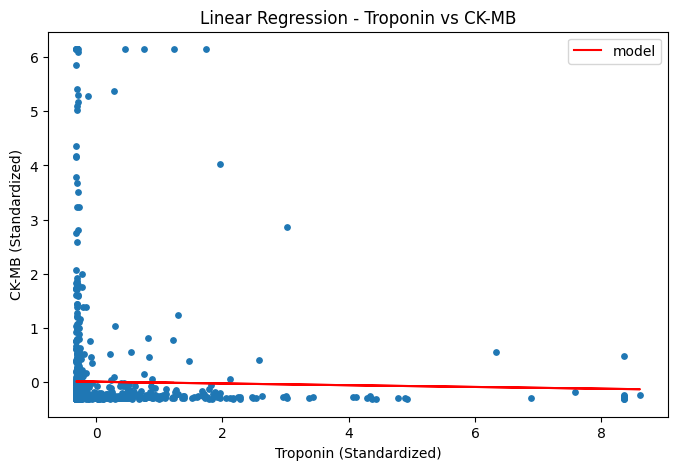

In [334]:
plt.figure(figsize=(8,5))

plt.scatter(scaled_df['troponin'], scaled_df['ck_mb'], s=15)

plt.plot(scaled_df['troponin'],y_pred, color='r', label='model')

plt.xlabel('Troponin (Standardized)')
plt.ylabel('CK-MB (Standardized)')
plt.legend()
plt.title('Linear Regression - Troponin vs CK-MB')

plt.show()

In [335]:
print("R2 Score:", r2_score(y, y_pred))

R2 Score: 0.0002562673017774131


The R2 score is extremely close to 0, which indicates that the linear regression model is unable to explain the relationship between troponin and CK-MB levels effectively.

This suggests that there is little to no linear relationship between the two biomarkers within this dataset. In other words, changes in troponin levels do not strongly predict changes in CK-MB values using a simple linear model.

In [336]:
df['gender'].value_counts()

gender
1    870
0    449
Name: count, dtype: int64

In [337]:
round(870 / (870 + 449), 2) * 100

66.0

~66% male

~33% female

In [338]:
male = df[df['gender'] == 1]
female = df[df['gender'] == 0]

In [339]:
male['result'].value_counts()

result
1    563
0    307
Name: count, dtype: int64

In [340]:
round(563 / (563 + 307), 2) * 100

65.0

~65% male observations with heart disease

~35% male observations without heart disease

In [341]:
female['result'].value_counts()

result
1    247
0    202
Name: count, dtype: int64

In [342]:
round(247 / (247 + 202), 2) * 100

55.00000000000001

~55% female observations with heart disease

~45% female observations without heart disease

According to gender, the data is distributed as follows. Approximately 2/3 of the observations are male, while 1/3 are female. A higher prevalence of heart disease is observed among males. Around 65% of the male observations are associated with heart disease, compared to approximately 55% among females. Nevertheless, in both groups, the proportion of individuals with heart disease is higher than the proportion of individuals without heart-related problems.

In [343]:
df

,age,gender,heart_rate,systolic_blood_pressure,diastolic_blood_pressure,blood_sugar,ck_mb,troponin,result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1
1317,54,1,58,117,68,443.0,5.80,0.359,1


In [344]:
male = df[df['gender'] == 1]
female = df[df['gender'] == 0]

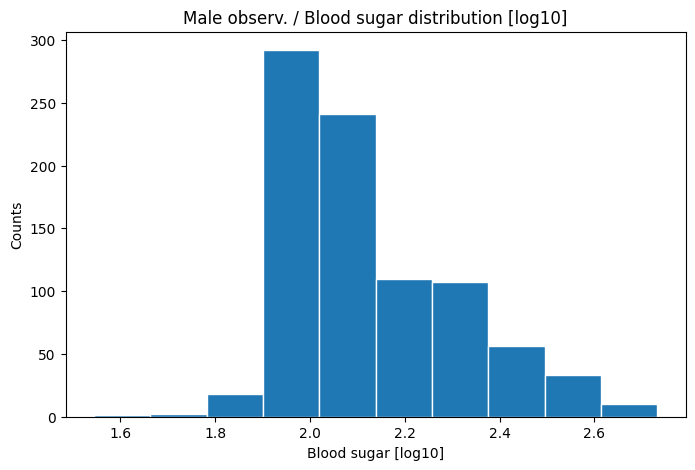

In [345]:
plt.figure(figsize=(8, 5))

plt.hist(log10(male['blood_sugar']), edgecolor='white')

plt.xlabel('Blood sugar [log10]')
plt.ylabel('Counts')
plt.title('Male observ. / Blood sugar distribution [log10]')
plt.show()

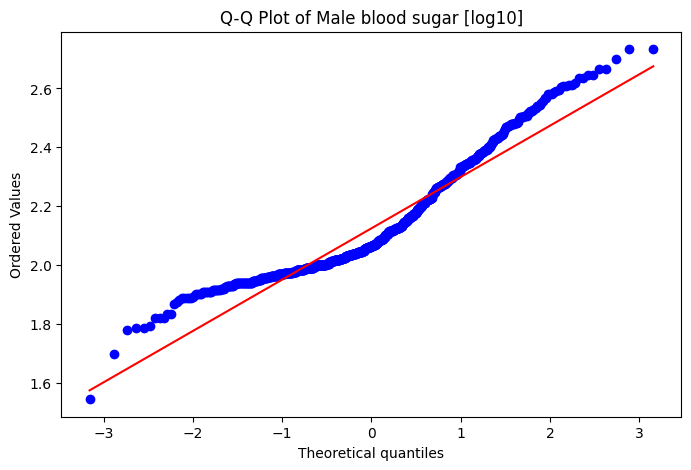

In [346]:
plt.figure(figsize=(8,5))
stats.probplot(log10(male['blood_sugar']), dist="norm", plot=plt)
plt.title('Q-Q Plot of Male blood sugar [log10]')
plt.show()

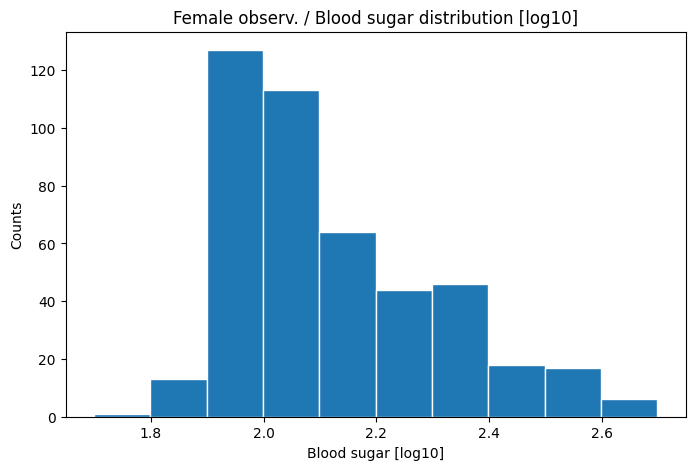

In [347]:
plt.figure(figsize=(8, 5))

plt.hist(log10(female['blood_sugar']), edgecolor='white')

plt.xlabel('Blood sugar [log10]')
plt.ylabel('Counts')
plt.title('Female observ. / Blood sugar distribution [log10]')
plt.show()

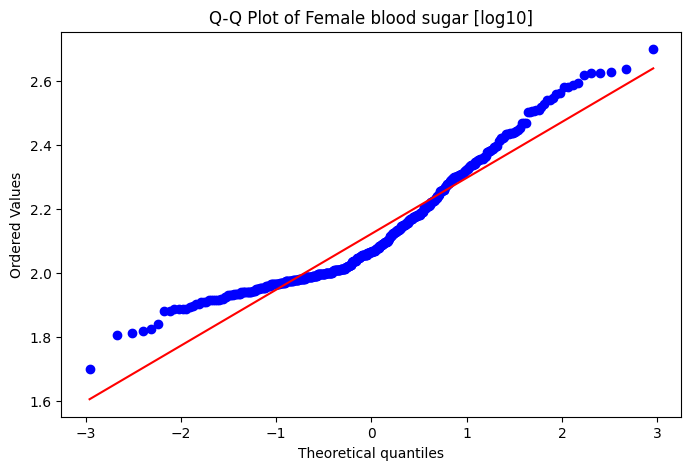

In [348]:
plt.figure(figsize=(8,5))
stats.probplot(log10(female['blood_sugar']), dist="norm", plot=plt)
plt.title('Q-Q Plot of Female blood sugar [log10]')
plt.show()

From both histograms and both Q-Q plots, we conclude that the distribution of the blood sugar data is not normal. Additionally, the two Q-Q plots appear visually very similar, which somewhat supports the initial hypothesis that the data may have been artificially generated.

Due to the relatively small size of the dataset, Random Forest will not be used in this analysis.

Although Random Forest is a powerful ensemble method, it may lead to overfitting when working with limited data.

Instead, Logistic Regression will be applied аs the primary classification model.

Logistic Regression is more suitable for smaller datasets, provides easier interpretability,
and performs efficiently for binary classification problems such as heart disease prediction.

In [349]:
# Features
X = df.drop(columns=['result'])

# Target
y = df['result']

In [350]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [351]:
# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7992424242424242
Precision: 0.8343558282208589
Recall: 0.8395061728395061
F1-score: 0.8369230769230769

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       102
           1       0.83      0.84      0.84       162

    accuracy                           0.80       264
   macro avg       0.79      0.79      0.79       264
weighted avg       0.80      0.80      0.80       264



In [352]:
cm0 = confusion_matrix(y_test, y_pred)

print(cm0)

[[ 75  27]
 [ 26 136]]


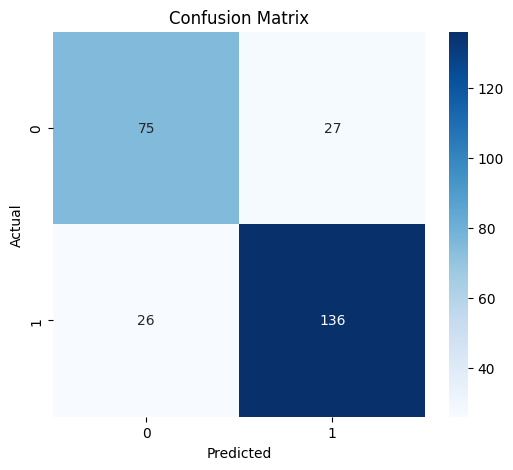

In [353]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm0,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [364]:
round(26 / (26 + 75), 2) * 100

26.0

The confusion matrix shows that the model performs relatively well in identifying positive cases, correctly classifying 136 patients with heart disease.

However, the model still produces 26 false negative predictions, meaning that some patients with heart disease are incorrectly classified as healthy.

The Logistic Regression model achieved an accuracy of approximately 80%, indicating moderate overall classification performance on the dataset.

Although the model produces acceptable results, the performance is not exceptionally high, which may be partially explained by the relatively small number of observations available for training. Limited data can restrict the model’s ability to generalize and learn more complex patterns associated with heart disease.

The precision score of approximately 0.82 suggests that most patients predicted as having heart disease were correctly classified. Additionally, the recall score of approximately 0.86 indicates that the model was able to identify a large proportion of positive heart disease cases.

The F1-score of approximately 0.84 demonstrates a relatively balanced relationship between precision and recall. However, the classification report also shows that the model performs better for patients with heart disease (class 1) than for patients without heart disease (class 0).

Overall, the model provides a reasonable baseline for heart disease prediction, but the relatively small dataset and moderate performance metrics suggest that additional data and more advanced modeling approaches could improve the predictive results.

Now, we will try to improve the model's results. We will scale the data and test the model using the scaled features.

In [354]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

In [355]:
scaled_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
    ))
])

In [356]:
scaled_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

In [357]:
y_pred = scaled_model.predict(X_test)

In [358]:
print(accuracy_score(y_test, y_pred))

0.7878787878787878


In [359]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.90      0.77        51
           1       0.92      0.72      0.81        81

    accuracy                           0.79       132
   macro avg       0.79      0.81      0.79       132
weighted avg       0.82      0.79      0.79       132



The model achieved an accuracy of approximately 79%, which indicates a moderate overall predictive performance. Although the results improved after applying feature scaling and class balancing, several limitations are still visible.

The classification report shows that the model performs significantly better when predicting class 1 compared to class 0 in terms of precision. However, the recall score for class 1 is only 0.72, meaning that a considerable number of positive cases are still being misclassified.

The difference between precision and recall suggests that the model struggles to maintain balanced performance across both classes. This may indicate that the dataset contains more complex and potentially non-linear relationships that logistic regression cannot fully capture.

Another important limitation is the relatively small number of observations available for training. A limited dataset reduces the model’s ability to generalize effectively and increases the risk of unstable predictions.

Overall, the model demonstrates acceptable baseline performance, but the results are not strong enough to be considered highly reliable for critical predictive tasks.

In [360]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[46  5]
 [23 58]]


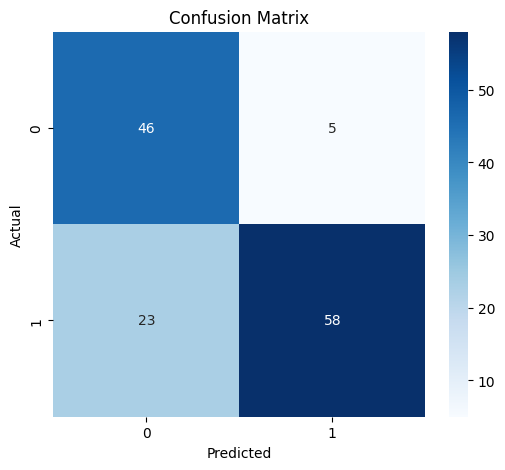

In [361]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [367]:
round(23 / (23 + 46), 2) * 100

33.0

The confusion matrix reveals that approximately 33% of the cases predicted as negative were actually positive cases. This false negative rate is relatively high and represents a significant limitation of the current model.

The confusion matrix shows that the model performs relatively well in identifying positive cases. A large number of actual positive observations were correctly classified as class 1, which indicates that the model is capable of detecting many high-risk patients.

However, a critical issue is still present. The model incorrectly classified 23 positive cases as class 0. These false negative predictions are particularly dangerous in a medical context because the model predicts that a patient is healthy when the patient may actually suffer from heart disease.

In real-world healthcare environments, this type of diagnostic error can lead to delayed treatment, missed medical intervention, and potentially severe consequences for patients. For this reason, reducing the number of false negatives should be considered a primary objective in future model improvements, even if it slightly decreases the overall accuracy.